# Clean Binary Federated Learning on DNN-EdgeIIoT

This notebook builds a centralized binary DNN and a five-client IID Flower FedAvg simulation. It uses a fresh leakage-aware pipeline, capture-group-disjoint splits, and new output folders; no artifacts from the earlier contaminated experiment are loaded.

## 1. Imports, CUDA check, and configuration

All important experiment settings are kept in one dictionary. Centralized training uses CUDA when available; simulated clients use CPU to avoid five competing GPU jobs.

In [1]:
import copy, json, os, random, shutil, sys, time, warnings
from collections import OrderedDict
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore', category=FutureWarning)
HERE = Path.cwd().resolve()
if (HERE / 'notebooks' / '02_simple_clean_federated_pipeline.ipynb').exists():
    PROJECT_ROOT = HERE
elif HERE.name == 'notebooks' and (HERE / '02_simple_clean_federated_pipeline.ipynb').exists():
    PROJECT_ROOT = HERE.parent
else:
    raise RuntimeError('Run this notebook from the experiment root or its notebooks directory.')
REPO_ROOT = next((p for p in (PROJECT_ROOT, *PROJECT_ROOT.parents) if (p / 'data').is_dir()), PROJECT_ROOT)
DATA_PATH = Path(os.environ.get('EDGEIIOT_DATASET', REPO_ROOT / 'data' / 'raw' / 'DNN-EdgeIIoT-dataset.csv'))
ARTIFACTS = PROJECT_ROOT / 'artifacts_clean'
RESULTS = PROJECT_ROOT / 'results_clean'
ARTIFACTS.mkdir(exist_ok=True); RESULTS.mkdir(exist_ok=True)

CONFIG = {
    'seed': 42, 'sample_fraction': 0.10, 'train_fraction': 0.70,
    'val_fraction': 0.15, 'test_fraction': 0.15, 'batch_size': 256,
    'hidden_layers': [128, 64, 32], 'dropout': [0.20, 0.10],
    'learning_rate': 0.001, 'central_epochs': 20, 'patience': 5,
    'local_epochs': 2, 'federated_rounds': 10, 'num_clients': 5,
    'client_names': ['Factory_A', 'Factory_B', 'Factory_C', 'Factory_D', 'Factory_E'],
    'threshold': 0.5, 'max_group_rows': 10000, 'leakage_flag_accuracy': 0.995,
}

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))
print('Centralized device:', DEVICE)
print('Dataset:', DATA_PATH)


Python: 3.11.0
PyTorch: 2.5.1+cu121 | CUDA: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Centralized device: cuda
Dataset: <local-project-root>\data\raw\DNN-EdgeIIoT-dataset.csv


## 2. Load and inspect the dataset

The full CSV is loaded so groups and duplicates can be handled before drawing the balanced 10% sample. Only `Attack_label` is the model target.

In [2]:
assert DATA_PATH.exists(), DATA_PATH
t0 = time.time()
raw = pd.read_csv(DATA_PATH, low_memory=False)
assert 'Attack_label' in raw and 'Attack_type' in raw
assert set(raw['Attack_label'].dropna().unique()) == {0, 1}
print(f'Loaded {len(raw):,} rows x {raw.shape[1]} columns in {time.time()-t0:.1f}s')
print(raw['Attack_label'].value_counts().rename(index={0: 'Normal', 1: 'Attack'}).to_string())


Loaded 2,219,201 rows x 63 columns in 59.8s
Attack_label
Normal    1615643
Attack     603558


## 3. Normalize values and construct capture groups

Groups are created before identifiers are removed. A group combines attack/capture block, a five-minute time window, and a bounded contiguous chunk for exceptionally large windows. These fields are grouping metadata only. Object columns are trimmed, missing tokens are normalized, equivalent zero spellings are canonicalized, and mostly numeric text is converted safely.

In [3]:
def make_capture_groups(df, max_group_rows):
    parts = df['frame.time'].astype('string').str.extract(r'(\d{2}):(\d{2}):(\d{2})', expand=True)
    seconds = (pd.to_numeric(parts[0], errors='coerce') * 3600
               + pd.to_numeric(parts[1], errors='coerce') * 60
               + pd.to_numeric(parts[2], errors='coerce'))
    delta = seconds - seconds.shift()
    new_run = (df['Attack_type'].ne(df['Attack_type'].shift())
               | (seconds.notna() & seconds.shift().notna() & (delta < -300)))
    run_id = new_run.cumsum()
    time_window = (seconds // 300).fillna(-1).astype('int64')
    base = (df['Attack_type'].astype('string') + '|run=' + run_id.astype('string')
            + '|window=' + time_window.astype('string'))
    chunk = base.groupby(base, sort=False).cumcount() // max_group_rows
    return (base + '|chunk=' + chunk.astype('string')).astype('string')

raw['_capture_group'] = make_capture_groups(raw, CONFIG['max_group_rows'])
assert raw.groupby('_capture_group')['Attack_label'].nunique().max() == 1

MISSING_TOKENS = {'', 'na', 'n/a', 'nan', 'none', 'null', '?', 'inf', '+inf', '-inf'}
def normalize_semantic_values(df):
    out = df.copy()
    converted = []
    text_cols = out.select_dtypes(include=['object', 'string']).columns.tolist()
    for col in text_cols:
        if col == '_capture_group':
            continue
        s = out[col].astype('string').str.strip()
        s = s.mask(s.str.lower().isin(MISSING_TOKENS))
        zero = (s.str.match(r'^[+-]?0+(?:\.0+)?$', na=False)
                | s.str.match(r'(?i)^0x0+$', na=False))
        s = s.mask(zero, '0')
        numeric = pd.to_numeric(s, errors='coerce')
        nonmissing = int(s.notna().sum())
        ratio = float(numeric.notna().sum() / nonmissing) if nonmissing else 0.0
        if nonmissing and ratio >= 0.98:
            out[col] = numeric.astype('float64')
            converted.append({'column': col, 'numeric_fraction': round(ratio, 4),
                              'nonmissing_values': nonmissing})
        else:
            out[col] = s
    out = out.replace([np.inf, -np.inf], np.nan)
    return out, pd.DataFrame(converted)

normalized, converted_numeric = normalize_semantic_values(raw)
print('Object columns converted to numeric:')
display(converted_numeric if len(converted_numeric) else pd.DataFrame({'result': ['none']}))
del raw


Object columns converted to numeric:


,column,numeric_fraction,nonmissing_values
0,arp.dst.proto_ipv4,0.9922,2219201
1,arp.src.proto_ipv4,0.9974,2219201
2,http.request.uri.query,0.9937,2219197
3,http.request.method,0.9855,2219201
4,http.referer,0.9997,2219201
5,http.request.full_uri,0.9856,2219201
6,http.request.version,0.9855,2219201
7,tcp.srcport,0.9998,2219201
8,dns.qry.name.len,0.9992,2219201
9,mqtt.conack.flags,1.0000,2219201


## 4. Remove contaminated fields and deduplicate the final representation

Known label proxies, capture identifiers, payload/text fields, absolute sequence identifiers, and unusable text are removed. Duplicate and conflicting rows are then handled using only the final candidate model features.

In [4]:
DROP_REASONS = {
    'Attack_type': 'attack name; grouping only',
    'frame.time': 'capture timestamp; grouping only',
    'ip.src_host': 'source host identity', 'ip.dst_host': 'destination host identity',
    'arp.src.proto_ipv4': 'host identity', 'arp.dst.proto_ipv4': 'host identity',
    'tcp.srcport': 'capture/source port identity', 'tcp.dstport': 'capture/target port identity',
    'udp.port': 'capture port identity', 'icmp.transmit_timestamp': 'capture timestamp',
    'tcp.payload': 'raw payload', 'mqtt.msg': 'raw message', 'http.file_data': 'payload/body',
    'http.request.full_uri': 'URL/payload content', 'http.request.uri.query': 'query/payload content',
    'http.referer': 'raw HTTP text', 'http.request.method': 'protocol text/source-format shortcut',
    'http.request.version': 'confirmed attack-content/schema pollution',
    'mqtt.conack.flags': 'confirmed source-format leakage',
    'mqtt.protoname': 'confirmed source-format leakage', 'mqtt.topic': 'confirmed source-format leakage',
    'dns.qry.name.len': 'confirmed source-format/schema pollution',
    'tcp.options': 'raw protocol text/high-cardinality identifier',
    'tcp.checksum': 'packet checksum/capture-specific', 'icmp.checksum': 'packet checksum/capture-specific',
    'tcp.seq': 'absolute sequence identifier', 'tcp.ack': 'absolute acknowledgement identifier',
    'tcp.ack_raw': 'absolute acknowledgement identifier', 'icmp.seq_le': 'packet sequence identifier',
    'udp.stream': 'capture stream identifier', 'mbtcp.trans_id': 'transaction identifier',
    'mbtcp.unit_id': 'device/unit identity', 'dns.retransmit_request_in': 'capture frame reference',
}
CONFIRMED_CONTAMINATED = {'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic',
                          'dns.qry.name.len', 'http.request.version'}
drop_rows = []
for col, reason in DROP_REASONS.items():
    if col in normalized.columns:
        drop_rows.append({'column': col, 'reason': reason})
normalized = normalized.drop(columns=[c for c in DROP_REASONS if c in normalized], errors='ignore')

# This clean teaching pipeline keeps numeric network measurements only.
for col in list(normalized.columns):
    if col in {'Attack_label', '_capture_group'}:
        continue
    if not pd.api.types.is_numeric_dtype(normalized[col]):
        n = int(normalized[col].nunique(dropna=True))
        reason = ('high-cardinality text' if n > 50 else 'remaining raw protocol text')
        drop_rows.append({'column': col, 'reason': reason})
        normalized = normalized.drop(columns=col)

for col in list(normalized.columns):
    if col in {'Attack_label', '_capture_group'}:
        continue
    if normalized[col].nunique(dropna=True) <= 1:
        drop_rows.append({'column': col, 'reason': 'constant or entirely missing'})
        normalized = normalized.drop(columns=col)

feature_cols = [c for c in normalized.columns if c not in {'Attack_label', '_capture_group'}]
assert 'Attack_type' not in feature_cols
assert CONFIRMED_CONTAMINATED.isdisjoint(feature_cols)
assert all(pd.api.types.is_numeric_dtype(normalized[c]) for c in feature_cols)
dropped_report = pd.DataFrame(drop_rows).drop_duplicates('column').sort_values('column').reset_index(drop=True)
display(dropped_report)

# Remove all feature patterns that have conflicting labels, then keep one row per pattern.
feature_hash = pd.util.hash_pandas_object(normalized[feature_cols], index=False)
label_span = pd.DataFrame({'h': feature_hash, 'y': normalized['Attack_label']}).groupby('h')['y'].agg(['min', 'max'])
ambiguous_hashes = set(label_span.index[label_span['min'] != label_span['max']])
ambiguous_mask = feature_hash.isin(ambiguous_hashes)
ambiguous_rows = int(ambiguous_mask.sum())
clean = normalized.loc[~ambiguous_mask].copy()
duplicate_mask = clean.duplicated(subset=feature_cols, keep='first')
duplicate_rows = int(duplicate_mask.sum())
clean = clean.loc[~duplicate_mask].reset_index(drop=True)
del normalized
print(f'Final candidate features: {len(feature_cols)}')
print(f'Ambiguous conflicting-label rows removed: {ambiguous_rows:,}')
print(f'Feature-identical same-label duplicates removed: {duplicate_rows:,}')
print(f'Clean unique rows remaining: {len(clean):,}')


,column,reason
0,Attack_type,attack name; grouping only
1,arp.dst.proto_ipv4,host identity
2,arp.src.proto_ipv4,host identity
3,dns.qry.name.len,confirmed source-format/schema pollution
4,dns.qry.type,constant or entirely missing
5,dns.retransmit_request_in,capture frame reference
6,frame.time,capture timestamp; grouping only
7,http.file_data,payload/body
8,http.referer,raw HTTP text
9,http.request.full_uri,URL/payload content


Final candidate features: 25
Ambiguous conflicting-label rows removed: 1,628,811
Feature-identical same-label duplicates removed: 574,563
Clean unique rows remaining: 15,827


## 5. Group-aware train, validation, and test splits

Capture groups—not packets—are assigned 70/15/15, stratified by the binary group label. The same group can never occur in two partitions.

In [5]:
group_table = clean.groupby('_capture_group').agg(label=('Attack_label', 'first'), rows=('Attack_label', 'size'))
assert clean.groupby('_capture_group')['Attack_label'].nunique().max() == 1
all_groups = group_table.index.to_numpy()
train_groups, temp_groups = train_test_split(
    all_groups, test_size=0.30, random_state=CONFIG['seed'],
    stratify=group_table.loc[all_groups, 'label'])
val_groups, test_groups = train_test_split(
    temp_groups, test_size=0.50, random_state=CONFIG['seed'],
    stratify=group_table.loc[temp_groups, 'label'])
group_sets = {'train': set(train_groups), 'validation': set(val_groups), 'test': set(test_groups)}
assert group_sets['train'].isdisjoint(group_sets['validation'])
assert group_sets['train'].isdisjoint(group_sets['test'])
assert group_sets['validation'].isdisjoint(group_sets['test'])
clean['_split'] = np.select(
    [clean['_capture_group'].isin(group_sets['train']), clean['_capture_group'].isin(group_sets['validation'])],
    ['train', 'validation'], default='test')
assigned = clean.groupby('_split').agg(groups=('_capture_group', 'nunique'), rows=('Attack_label', 'size'),
                                           normal=('Attack_label', lambda s: int((s == 0).sum())),
                                           attack=('Attack_label', lambda s: int((s == 1).sum())))
display(assigned.loc[['train', 'validation', 'test']])
print('Group overlap: 0 (asserted)')


,groups,rows,normal,attack
_split,,,,
train,71,10337,1321,9016
validation,15,3923,1620,2303
test,16,1567,258,1309


Group overlap: 0 (asserted)


## 6. Balanced 10% sample

Sampling occurs only after group assignment. Each partition is sampled without replacement and balanced 50/50, with target sizes proportional to 70/15/15.

In [6]:
target_total = int(round(len(clean) * CONFIG['sample_fraction']))
targets = {'train': int(round(target_total * 0.70)),
           'validation': int(round(target_total * 0.15))}
targets['test'] = target_total - targets['train'] - targets['validation']

def balanced_take(frame, target_rows, seed):
    normal = frame[frame['Attack_label'] == 0]
    attack = frame[frame['Attack_label'] == 1]
    n_each = min(target_rows // 2, len(normal), len(attack))
    return (pd.concat([normal.sample(n_each, random_state=seed),
                       attack.sample(n_each, random_state=seed + 1)])
            .sample(frac=1, random_state=seed + 2).reset_index(drop=True))

splits = {}
for i, name in enumerate(['train', 'validation', 'test']):
    splits[name] = balanced_take(clean[clean['_split'] == name], targets[name], CONFIG['seed'] + 10*i)
train_df, val_df, test_df = splits['train'], splits['validation'], splits['test']
summary = pd.DataFrame([{
    'split': name, 'assigned_groups': len(group_sets[name]),
    'sampled_groups': df['_capture_group'].nunique(), 'rows': len(df),
    'normal': int((df['Attack_label'] == 0).sum()), 'attack': int((df['Attack_label'] == 1).sum())
} for name, df in splits.items()]).set_index('split')
display(summary)
print(f'Balanced sample: {sum(len(x) for x in splits.values()):,} rows '
      f'({100*sum(len(x) for x in splits.values())/len(clean):.2f}% of cleaned unique rows)')

# Exact final-feature rows and group identifiers are disjoint across splits.
split_hashes = {name: set(pd.util.hash_pandas_object(df[feature_cols], index=False).tolist()) for name, df in splits.items()}
assert split_hashes['train'].isdisjoint(split_hashes['validation'])
assert split_hashes['train'].isdisjoint(split_hashes['test'])
assert split_hashes['validation'].isdisjoint(split_hashes['test'])
assert set(train_df['Attack_label'].unique()) == {0, 1}
print('Confirmed: zero group overlap and zero exact-feature overlap across splits.')
del clean


,assigned_groups,sampled_groups,rows,normal,attack
split,,,,,
train,71,59,1108,554,554
validation,15,11,236,118,118
test,16,12,238,119,119


Balanced sample: 1,582 rows (10.00% of cleaned unique rows)
Confirmed: zero group overlap and zero exact-feature overlap across splits.


## 7. Training-only leakage check and preprocessing

A one-level decision tree checks each feature using training rows only. Near-perfect splits are flagged for review. Median imputation and standardization are then fitted only on the training split.

In [7]:
X_train_raw = train_df[feature_cols].copy(); y_train = train_df['Attack_label'].to_numpy(np.float32)
X_val_raw = val_df[feature_cols].copy(); y_val = val_df['Attack_label'].to_numpy(np.float32)
X_test_raw = test_df[feature_cols].copy(); y_test = test_df['Attack_label'].to_numpy(np.float32)

audit_rows = []
for col in feature_cols:
    x = X_train_raw[[col]].replace([np.inf, -np.inf], np.nan)
    fill = x[col].median()
    stump = DecisionTreeClassifier(max_depth=1, min_samples_leaf=50, random_state=CONFIG['seed'])
    stump.fit(x.fillna(fill), y_train.astype(int))
    acc = float(stump.score(x.fillna(fill), y_train.astype(int)))
    audit_rows.append({'feature': col, 'training_stump_accuracy': acc,
                       'flagged': acc >= CONFIG['leakage_flag_accuracy']})
leakage_audit = pd.DataFrame(audit_rows).sort_values('training_stump_accuracy', ascending=False)
display(leakage_audit.head(8).round(4))
flagged = leakage_audit.loc[leakage_audit['flagged'], 'feature'].tolist()
print('Near-perfect training-only flags:', flagged if flagged else 'none')
# All known source/session identifiers were explicitly removed above. Any new flag is reported, not used blindly.

preprocessor = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler())])
X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_val = preprocessor.transform(X_val_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)
for name, array in [('train', X_train), ('validation', X_val), ('test', X_test)]:
    assert np.isfinite(array).all(), f'NaN/Inf in {name}'
assert preprocessor.n_features_in_ == len(feature_cols)
joblib.dump(preprocessor, ARTIFACTS / 'preprocessor.joblib')
(ARTIFACTS / 'feature_list.json').write_text(json.dumps(feature_cols, indent=2), encoding='utf-8')
dropped_report.to_csv(ARTIFACTS / 'dropped_columns.csv', index=False)
print('Processed shapes:', X_train.shape, X_val.shape, X_test.shape)
print('Confirmed: preprocessing fitted on training rows only; no NaN or infinity remains.')


,feature,training_stump_accuracy,flagged
12,dns.qry.name,0.9395,False
11,udp.time_delta,0.8014,False
14,dns.retransmission,0.7121,False
13,dns.qry.qu,0.7085,False
10,tcp.len,0.6498,False
9,tcp.flags.ack,0.6381,False
8,tcp.flags,0.6381,False
0,arp.opcode,0.5000,False


Near-perfect training-only flags: none
Processed shapes: (1108, 25) (236, 25) (238, 25)
Confirmed: preprocessing fitted on training rows only; no NaN or infinity remains.


## 8. Centralized DNN baseline

The default MLP is trained first with early stopping on validation F1. If validation accuracy stays below 96%, two modest alternatives are tried. The untouched test set is evaluated once after selection.

In [8]:
class BinaryMLP(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=(0.20, 0.10)):
        super().__init__()
        layers, previous = [], input_dim
        for i, width in enumerate(hidden):
            layers += [nn.Linear(previous, width), nn.ReLU()]
            if i < len(dropout): layers.append(nn.Dropout(dropout[i]))
            previous = width
        layers.append(nn.Linear(previous, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def loader_for(X, y, shuffle):
    ds = TensorDataset(torch.from_numpy(np.asarray(X, np.float32)),
                       torch.from_numpy(np.asarray(y, np.float32)).view(-1, 1))
    return DataLoader(ds, batch_size=CONFIG['batch_size'], shuffle=shuffle)

def metric_bundle(y, prob, loss=None):
    y = np.asarray(y).astype(int); pred = (np.asarray(prob) >= CONFIG['threshold']).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    out = {'accuracy': float((pred == y).mean()),
           'precision': float(precision_score(y, pred, zero_division=0)),
           'recall': float(recall_score(y, pred, zero_division=0)),
           'f1': float(f1_score(y, pred, zero_division=0)),
           'roc_auc': float(roc_auc_score(y, prob)),
           'pr_auc': float(average_precision_score(y, prob)),
           'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
           'fpr': float(fp / (fp + tn)) if fp + tn else 0.0,
           'fnr': float(fn / (fn + tp)) if fn + tp else 0.0}
    if loss is not None: out['loss'] = float(loss)
    return out

@torch.no_grad()
def evaluate_array(model, X, y, device):
    model.to(device).eval(); criterion = nn.BCEWithLogitsLoss()
    probabilities, total_loss, n = [], 0.0, 0
    for xb, yb in loader_for(X, y, False):
        xb, yb = xb.to(device), yb.to(device); logits = model(xb); loss = criterion(logits, yb)
        probabilities.append(torch.sigmoid(logits).cpu().numpy().ravel())
        total_loss += loss.item() * len(xb); n += len(xb)
    return metric_bundle(y, np.concatenate(probabilities), total_loss / n)

def train_candidate(spec):
    set_seed(CONFIG['seed'])
    model = BinaryMLP(X_train.shape[1], spec['hidden'], spec['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=spec['lr'])
    criterion = nn.BCEWithLogitsLoss(); train_loader = loader_for(X_train, y_train, True)
    best_f1, best_state, best_metrics, stale = -1.0, None, None, 0
    history = []
    for epoch in range(1, spec['epochs'] + 1):
        model.train(); running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE); optimizer.zero_grad()
            loss = criterion(model(xb), yb); loss.backward(); optimizer.step()
            running += loss.item() * len(xb)
        val_metrics = evaluate_array(model, X_val, y_val, DEVICE)
        history.append({'epoch': epoch, 'train_loss': running/len(X_train),
                        'val_loss': val_metrics['loss'], 'val_accuracy': val_metrics['accuracy'],
                        'val_f1': val_metrics['f1']})
        if val_metrics['f1'] > best_f1 + 1e-6:
            best_f1, best_state, best_metrics, stale = val_metrics['f1'], copy.deepcopy(model.state_dict()), val_metrics, 0
        else: stale += 1
        if stale >= CONFIG['patience']: break
    model.load_state_dict(best_state)
    return model, best_metrics, pd.DataFrame(history)

candidate_specs = [
    {'name': 'default', 'hidden': [128,64,32], 'dropout': [0.20,0.10], 'lr': 0.001, 'epochs': 20},
    {'name': 'wider', 'hidden': [256,128,64], 'dropout': [0.10,0.10], 'lr': 0.001, 'epochs': 25},
    {'name': 'slower_lr', 'hidden': [128,64,32], 'dropout': [0.10,0.10], 'lr': 0.0003, 'epochs': 30},
]
trained = []
model, metrics, history = train_candidate(candidate_specs[0])
trained.append((candidate_specs[0], model, metrics, history))
if metrics['accuracy'] < 0.96:
    for spec in candidate_specs[1:]:
        m, vm, h = train_candidate(spec); trained.append((spec, m, vm, h))
selection = pd.DataFrame([{'name': s['name'], 'hidden': str(s['hidden']), 'lr': s['lr'],
                           'val_accuracy': vm['accuracy'], 'val_f1': vm['f1'], 'epochs_run': len(h)}
                          for s, m, vm, h in trained]).sort_values(['val_f1','val_accuracy'], ascending=False)
display(selection.round(4))
best_name = selection.iloc[0]['name']
selected_spec, centralized_model, selected_val, selected_history = next(x for x in trained if x[0]['name'] == best_name)
assert centralized_model.net[0].in_features == X_train.shape[1]
torch.save({'state_dict': centralized_model.state_dict(), 'input_dim': X_train.shape[1],
            'spec': selected_spec}, ARTIFACTS / 'centralized_model.pt')
print('Selected by validation F1:', selected_spec)


,name,hidden,lr,val_accuracy,val_f1,epochs_run
0,default,"[128, 64, 32]",0.001,0.9958,0.9957,7


Selected by validation F1: {'name': 'default', 'hidden': [128, 64, 32], 'dropout': [0.2, 0.1], 'lr': 0.001, 'epochs': 20}


,centralized_test
accuracy,0.97059
precision,0.99123
recall,0.94958
f1,0.96996
roc_auc,0.99167
pr_auc,0.99349
tn,118.00000
fp,1.00000
fn,6.00000
tp,113.00000


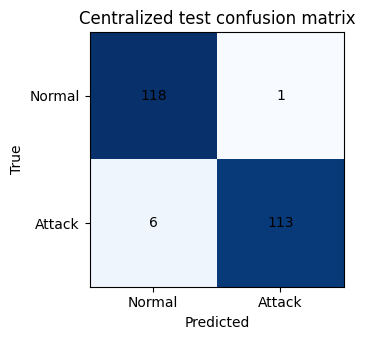

In [9]:
TEST_TOUCHED_FOR_FITTING = False
assert not TEST_TOUCHED_FOR_FITTING
centralized_test = evaluate_array(centralized_model, X_test, y_test, DEVICE)
(RESULTS / 'centralized_final_metrics.json').write_text(json.dumps(centralized_test, indent=2), encoding='utf-8')
display(pd.Series(centralized_test).to_frame('centralized_test').round(5))
cm = np.array([[centralized_test['tn'], centralized_test['fp']],
               [centralized_test['fn'], centralized_test['tp']]])
fig, ax = plt.subplots(figsize=(4, 3.5)); im = ax.imshow(cm, cmap='Blues')
ax.set(xticks=[0,1], yticks=[0,1], xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'],
       xlabel='Predicted', ylabel='True', title='Centralized test confusion matrix')
for i in range(2):
    for j in range(2): ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center')
plt.tight_layout(); plt.show()


## 9. Five IID client partitions

Only training rows are partitioned. Each class is shuffled and divided evenly so clients are disjoint, similarly sized, and approximately 50/50.

,client,rows,normal,attack
0,Factory_A,222,111,111
1,Factory_B,222,111,111
2,Factory_C,222,111,111
3,Factory_D,222,111,111
4,Factory_E,220,110,110


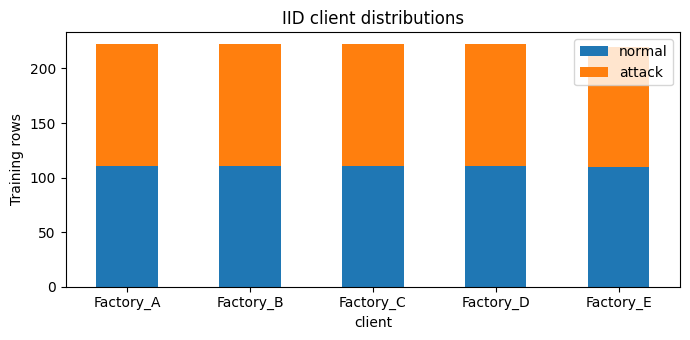

Confirmed: five non-overlapping clients with one shared architecture.


In [10]:
rng = np.random.default_rng(CONFIG['seed'])
partitions = {name: [] for name in CONFIG['client_names']}
for label in [0, 1]:
    idx = np.where(y_train.astype(int) == label)[0]; rng.shuffle(idx)
    for name, chunk in zip(CONFIG['client_names'], np.array_split(idx, CONFIG['num_clients'])):
        partitions[name].append(chunk)
for name in partitions:
    partitions[name] = np.concatenate(partitions[name]); rng.shuffle(partitions[name])
assert len(partitions) == 5
all_client_idx = np.concatenate(list(partitions.values()))
assert len(np.unique(all_client_idx)) == len(all_client_idx) == len(X_train)
architecture_signatures = []
rows = []
for name, idx in partitions.items():
    labels = y_train[idx].astype(int)
    m = BinaryMLP(X_train.shape[1], selected_spec['hidden'], selected_spec['dropout'])
    architecture_signatures.append(str(m))
    rows.append({'client': name, 'rows': len(idx), 'normal': int((labels==0).sum()),
                 'attack': int((labels==1).sum())})
assert len(set(architecture_signatures)) == 1
client_distribution = pd.DataFrame(rows)
client_distribution.to_csv(RESULTS / 'client_distributions.csv', index=False)
display(client_distribution)
ax = client_distribution.set_index('client')[['normal','attack']].plot.bar(stacked=True, figsize=(7,3.5))
ax.set_ylabel('Training rows'); ax.set_title('IID client distributions'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print('Confirmed: five non-overlapping clients with one shared architecture.')


## 10. Flower FedAvg simulation

This uses Flower's current Message/Record `FedAvg` strategy. All five clients train sequentially in one process each round, which is stable on a one-GPU laptop; Flower then weights their updates by number of examples. Central preprocessing is a stated simulation convenience, not a privacy-preserving federated preprocessing protocol.

Reference: https://flower.ai/docs/framework/ref-api/flwr.serverapp.strategy.FedAvg.html

Flower: 1.32.1 | execution: sequential in-process clients


INFO :      aggregate_train: Received 5 results and 0 failures


INFO :      aggregate_train: Received 5 results and 0 failures


INFO :      aggregate_train: Received 5 results and 0 failures


INFO :      aggregate_train: Received 5 results and 0 failures


...

INFO :      aggregate_train: Received 5 results and 0 failures


INFO :      aggregate_train: Received 5 results and 0 failures


INFO :      aggregate_train: Received 5 results and 0 failures


Federated wall time: 2.6s | best round: 3


,round,validation_loss,validation_accuracy,validation_f1
0,0,0.68957,0.50000,0.00000
1,1,0.67552,0.50000,0.00000
2,2,0.66077,0.55932,0.21212
3,3,0.64502,0.99576,0.99574
4,4,0.62593,0.99576,0.99574
5,5,0.60439,0.99576,0.99574
6,6,0.58098,0.99576,0.99574
7,7,0.55380,0.99576,0.99574
8,8,0.52208,0.99576,0.99574
9,9,0.48783,0.99576,0.99574


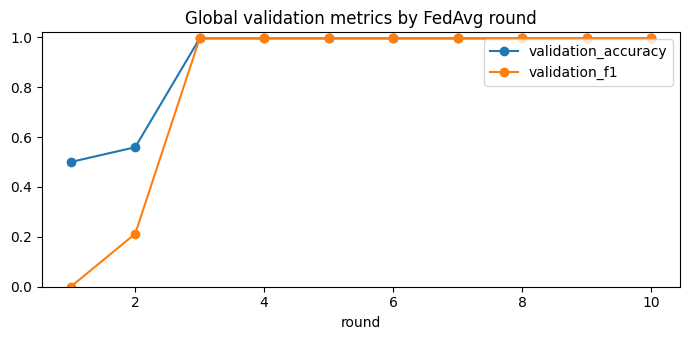

In [11]:
import flwr as fl
from flwr.app import ArrayRecord, Message, MetricRecord, RecordDict
from flwr.serverapp.strategy import FedAvg

print('Flower:', fl.__version__, '| execution: sequential in-process clients')

def get_parameters(model):
    return [v.detach().cpu().numpy() for v in model.state_dict().values()]
def set_parameters(model, parameters):
    state = OrderedDict((k, torch.tensor(v)) for k, v in zip(model.state_dict().keys(), parameters))
    model.load_state_dict(state, strict=True)

strategy = FedAvg(
    fraction_train=1.0, fraction_evaluate=0.0, min_train_nodes=5,
    min_evaluate_nodes=0, min_available_nodes=5, weighted_by_key='num-examples')
fed_records = {'rounds': [], 'best_f1': -1.0, 'best_round': -1}
FED_MODEL_PATH = ARTIFACTS / 'federated_global_model.pt'

def evaluate_global(server_round, parameters):
    model = BinaryMLP(X_val.shape[1], selected_spec['hidden'], selected_spec['dropout'])
    set_parameters(model, parameters)
    metrics = evaluate_array(model, X_val, y_val, torch.device('cpu'))
    fed_records['rounds'].append({
        'round': server_round, 'validation_loss': metrics['loss'],
        'validation_accuracy': metrics['accuracy'], 'validation_f1': metrics['f1']})
    if server_round > 0 and metrics['f1'] > fed_records['best_f1']:
        fed_records['best_f1'], fed_records['best_round'] = metrics['f1'], server_round
        torch.save({'state_dict': model.state_dict(), 'input_dim': X_val.shape[1],
                    'spec': selected_spec, 'round': server_round}, FED_MODEL_PATH)

set_seed(CONFIG['seed'])
initial_model = BinaryMLP(X_train.shape[1], selected_spec['hidden'], selected_spec['dropout'])
global_parameters = get_parameters(initial_model)
evaluate_global(0, global_parameters)

t0 = time.time()
for server_round in range(1, CONFIG['federated_rounds'] + 1):
    replies = []
    for client_id, name in enumerate(CONFIG['client_names']):
        idx = partitions[name]
        local_model = BinaryMLP(X_train.shape[1], selected_spec['hidden'], selected_spec['dropout'])
        set_parameters(local_model, global_parameters)
        torch.manual_seed(CONFIG['seed'] + client_id * 100 + server_round)
        optimizer = torch.optim.Adam(local_model.parameters(), lr=selected_spec['lr'])
        criterion = nn.BCEWithLogitsLoss(); local_model.train(); loss_sum = 0.0; seen = 0
        for _ in range(CONFIG['local_epochs']):
            for xb, yb in loader_for(X_train[idx], y_train[idx], True):
                optimizer.zero_grad(); loss = criterion(local_model(xb), yb)
                loss.backward(); optimizer.step()
                loss_sum += loss.item() * len(xb); seen += len(xb)
        content = RecordDict({
            'arrays': ArrayRecord(numpy_ndarrays=get_parameters(local_model)),
            'metrics': MetricRecord({'num-examples': len(idx), 'train-loss': loss_sum / seen})})
        replies.append(Message(dst_node_id=0, message_type='train', content=content))
    aggregated, _ = strategy.aggregate_train(server_round, replies)
    assert aggregated is not None, 'Flower did not return an aggregated model'
    global_parameters = aggregated.to_numpy_ndarrays()
    evaluate_global(server_round, global_parameters)

print(f'Federated wall time: {time.time()-t0:.1f}s | best round: {fed_records["best_round"]}')
round_metrics = pd.DataFrame(fed_records['rounds']).sort_values('round').reset_index(drop=True)
round_metrics.to_csv(RESULTS / 'federated_round_metrics.csv', index=False)
display(round_metrics.round(5))
ax = round_metrics[round_metrics['round'] > 0].plot(x='round', y=['validation_accuracy','validation_f1'],
                                                        marker='o', ylim=(0,1.02), figsize=(7,3.5))
ax.set_title('Global validation metrics by FedAvg round'); plt.tight_layout(); plt.show()


## 11. Final federated evaluation and comparison

The best validation-F1 global checkpoint is evaluated once on the same untouched group-disjoint test split, then compared with the centralized baseline.

In [12]:
checkpoint = torch.load(FED_MODEL_PATH, map_location='cpu', weights_only=True)
federated_model = BinaryMLP(checkpoint['input_dim'], checkpoint['spec']['hidden'], checkpoint['spec']['dropout'])
federated_model.load_state_dict(checkpoint['state_dict'])
federated_test = evaluate_array(federated_model, X_test, y_test, torch.device('cpu'))
fed_output = {'best_round': int(checkpoint['round']), **federated_test}
(RESULTS / 'federated_final_metrics.json').write_text(json.dumps(fed_output, indent=2), encoding='utf-8')
comparison = pd.DataFrame({
    'centralized': {k: centralized_test[k] for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','fpr','fnr']},
    'federated': {k: federated_test[k] for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','fpr','fnr']}
})
display(comparison.round(5))
print('Federated confusion matrix:', [[federated_test['tn'], federated_test['fp']],
                                      [federated_test['fn'], federated_test['tp']]])
assert not TEST_TOUCHED_FOR_FITTING if 'TEST_TOUCHED_FOR_FITTING' in globals() else True


,centralized,federated
accuracy,0.97059,0.97059
precision,0.99123,0.99123
recall,0.94958,0.94958
f1,0.96996,0.96996
roc_auc,0.99167,0.99237
pr_auc,0.99349,0.99431
fpr,0.00840,0.00840
fnr,0.05042,0.05042


Federated confusion matrix: [[118, 1], [6, 113]]


## 12. Save final artifacts and summary

All outputs belong to this clean run. Client arrays stay in memory during the sequential simulation, so no reusable shard cache is created.

In [13]:
print('Sequential Flower simulation used no disk cache.')
run_summary = {
    'clean_unique_rows': int(sum(len(x) for x in splits.values())),
    'final_feature_count': len(feature_cols),
    'grouping_method': 'Attack_type capture block + time-reset run + 5-minute window + bounded contiguous chunk',
    'group_overlap': 0, 'centralized': centralized_test, 'federated': federated_test,
    'accuracy_target_reached': bool(max(centralized_test['accuracy'], federated_test['accuracy']) >= 0.96),
}
(RESULTS / 'run_summary.json').write_text(json.dumps(run_summary, indent=2), encoding='utf-8')
print(f"Cleaned balanced sample size: {run_summary['clean_unique_rows']:,}")
print('Final feature count:', run_summary['final_feature_count'])
print('Grouping:', run_summary['grouping_method'])
print('Group overlap: 0')
print(f"Centralized: accuracy={centralized_test['accuracy']:.4f}, F1={centralized_test['f1']:.4f}")
print(f"Federated:   accuracy={federated_test['accuracy']:.4f}, F1={federated_test['f1']:.4f}")
print('96% target reached:', run_summary['accuracy_target_reached'])
print('Saved clean artifacts to:', ARTIFACTS)
print('Saved clean results to:', RESULTS)


Sequential Flower simulation used no disk cache.
Cleaned balanced sample size: 1,582
Final feature count: 25
Grouping: Attack_type capture block + time-reset run + 5-minute window + bounded contiguous chunk
Group overlap: 0
Centralized: accuracy=0.9706, F1=0.9700
Federated:   accuracy=0.9706, F1=0.9700
96% target reached: True
Saved clean artifacts to: <local-project-root>\edgeiiot_federated\artifacts_clean
Saved clean results to: <local-project-root>\edgeiiot_federated\results_clean


## 13. Limitations

This is a clean educational simulation, not evidence of performance on unseen factories. Clients are IID partitions from one laboratory dataset; preprocessing is centralized for convenience; bounded source chunks are only proxies for capture sessions; and no privacy, secure aggregation, or real network deployment is implemented. A lower score than the old notebook is expected because source-format and packet-level leakage have been removed.